In [1]:
!pip install pami==2026.1.19.1
# pami-2026.1.19.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 6.3 MB/s eta 0:00:00
  Created wheel for JsonForm: filename=JsonForm-0.0.2-py3-none-any.whl size=3311 sha256=10f0824724a687ae2f1b4ef5dde480e833bcee8308bc4f24efbceef82c3a690e
  Stored in directory: /root/.cache/pip/wheels/0b/29/3c/f5b5085becdbee0b282b60cda0028607f67adf8f099316a4a7
  Created wheel for JsonSir: filename=JsonSir-0.0.2-py3-none-any.whl size=4754 sha256=0e9feee3b19f35720a0091d3ac4

In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Memuat Data

In [3]:
print("Memuat dataset...")
print("\nPenggunaan RAM tanpa type-casting:\n========================")
df = pd.read_csv("/kaggle/input/datasets/felixoctavius/online-retail-ii/cleaned_uk_v2.csv")
df.info(memory_usage='deep')
print(df.head())

Memuat dataset...

Penggunaan RAM tanpa type-casting:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699610 entries, 0 to 699609
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      699610 non-null  int64  
 1   StockCode    699610 non-null  object 
 2   Description  699610 non-null  object 
 3   Quantity     699610 non-null  int64  
 4   InvoiceDate  699610 non-null  object 
 5   Price        699610 non-null  float64
 6   Customer ID  699610 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 153.3 MB
   Invoice StockCode                          Description  Quantity  \
0   489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1   489434    79323P                   PINK CHERRY LIGHTS        12   
2   489434    79323W                  WHITE CHERRY LIGHTS        12   
3   489434     22041          RECORD FRAME 7" SINGLE SIZE        48   
4   489434     21232       STRA

In [4]:
optimized_dtypes = {
    'Quantity': np.int32,      # 32-bit int instead of default 64-bit
    'Price': np.float32,       # 32-bit float instead of default 64-bit
    'Customer ID': 'Int32',    # Pandas Nullable Integer (handles NaNs without using float64)
    'StockCode': 'category'    # Categorical (repetitive product codes)
}

df = pd.read_csv(
    '/kaggle/input/datasets/felixoctavius/online-retail-ii/cleaned_uk_v2.csv', 
    dtype=optimized_dtypes,
    parse_dates=['InvoiceDate']
)

df['Description'] = df['Description'].astype('category')
df['Invoice'] = df['Invoice'].astype('category')

print("\nPenggunaan RAM dengan type-casting:\n========================")
df.info(memory_usage='deep')
print(df.head()) # memastikan data tidak berubah


Penggunaan RAM dengan type-casting:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699610 entries, 0 to 699609
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      699610 non-null  category      
 1   StockCode    699610 non-null  category      
 2   Description  699610 non-null  category      
 3   Quantity     699610 non-null  int32         
 4   InvoiceDate  699610 non-null  datetime64[ns]
 5   Price        699610 non-null  float32       
 6   Customer ID  699610 non-null  Int32         
dtypes: Int32(1), category(3), datetime64[ns](1), float32(1), int32(1)
memory usage: 21.4 MB
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041          R

In [5]:
# Snippet EDA untuk Statistika Dasar Sebelum Pemrosesan
print("=== Statistika Deskriptif Dataset ===")
print(df.describe(include='all'))

print("\n=== Pemeriksaan Nilai yang Hilang (Missing Values) ===")
print(df.isnull().sum())

print("\n=== Informasi Rentang Waktu Transaksi ===")
print(f"Tanggal Transaksi Awal: {df['InvoiceDate'].min()}")
print(f"Tanggal Transaksi Akhir: {df['InvoiceDate'].max()}")

=== Statistika Deskriptif Dataset ===
         Invoice StockCode                         Description       Quantity  \
count   699610.0    699610                              699610  699610.000000   
unique   33361.0      4605                                4567            NaN   
top     576339.0    85123A  CREAM HANGING HEART T-LIGHT HOLDER            NaN   
freq       541.0      4834                                4834            NaN   
mean         NaN       NaN                                 NaN      12.182051   
min          NaN       NaN                                 NaN       1.000000   
25%          NaN       NaN                                 NaN       2.000000   
50%          NaN       NaN                                 NaN       4.000000   
75%          NaN       NaN                                 NaN      12.000000   
max          NaN       NaN                                 NaN   80995.000000   
std          NaN       NaN                                 NaN     143.

# 2. Pembuatan Kolom Omzet

In [6]:
# Membuat kolom Total Value (Monetary)
df['Revenue'] = df['Quantity'] * df['Price']

In [7]:
# Cek nilai revenue di persentil 5% dan 10% terbawah dan 5% dan 10% teratas (kondisi di mana revenue > 0)
clean_revenue = df[df['Revenue'] > 0]['Revenue']
p5 = clean_revenue.quantile(0.05)
p10 = clean_revenue.quantile(0.10)
p95 = clean_revenue.quantile(0.95)
p90 = clean_revenue.quantile(0.90)

print(f"5% transaksi terbawah bernilai di bawah: £{p5:.2f}")
print(f"10% transaksi terbawah bernilai di bawah: £{p10:.2f}")
print(f"5% transaksi teratas bernilai di atas: £{p95:.2f}")
print(f"10% transaksi teratas bernilai di atas: £{p90:.2f}")

5% transaksi terbawah bernilai di bawah: £1.25
10% transaksi terbawah bernilai di bawah: £1.95
5% transaksi teratas bernilai di atas: £60.00
10% transaksi teratas bernilai di atas: £33.90


# RFM Clustering

# 3. Kalkulasi RFM

In [8]:
print("Menghitung metrik RFM...")
# Menentukan tanggal acuan (snapshot date) yaitu 1 hari setelah tanggal transaksi terakhir
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

Menghitung metrik RFM...


In [9]:
# Agregasi data pada level Customer
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                    # Frequency
    'Revenue': 'sum'                                        # Monetary
})

In [10]:
# Mengganti nama kolom agar lebih intuitif
rfm.rename(columns={'InvoiceDate': 'Recency',
                    'Invoice': 'Frequency',
                    'Revenue': 'Monetary'}, inplace=True)

In [11]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,3,77352.957164
12608,405,1,415.790003
12745,487,2,723.850002
12746,541,1,254.549996
12747,2,26,8898.480012


In [12]:
# Implementing the Original Online Retail Dataset Paper's 1% Rare Value Filter ===
print(f"Total customer profiles before filtering: {len(rfm)}")

# The paper targeted long-tail extremes in Frequency and Monetary distributions
# We use the 99th percentile to exclude the top 1% "rare" extreme values
freq_cutoff = rfm['Frequency'].quantile(0.99)
monetary_cutoff = rfm['Monetary'].quantile(0.99)

print(f"Frequency Cutoff (99th percentile): {freq_cutoff}")
print(f"Monetary Cutoff (99th percentile): £{monetary_cutoff:,.2f}")

# Filter the dataframe to isolate and remove these outliers
rfm_filtered = rfm[(rfm['Frequency'] <= freq_cutoff) & (rfm['Monetary'] <= monetary_cutoff)].copy()

print(f"Total customer profiles after filtering: {len(rfm_filtered)}")
print(f"Successfully isolated {len(rfm) - len(rfm_filtered)} extreme outlier profiles.")

# Overwrite the rfm variable so the rest of your notebook uses the filtered data
rfm = rfm_filtered

Total customer profiles before filtering: 5334
Frequency Cutoff (99th percentile): 46.0
Monetary Cutoff (99th percentile): £26,395.15
Total customer profiles after filtering: 5260
Successfully isolated 74 extreme outlier profiles.


# 4. Pra-pemrosesan untuk Klasterisasi

In [13]:
# Menangani skewness dengan Log Transformation (menggunakan np.log1p untuk menangani nilai 0)
rfm_log = np.log1p(rfm)

In [14]:
# Standardisasi data agar memiliki mean=0 dan variance=1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

# 5. Klasterisasi menggunakan K-Means

Mengeksekusi evaluasi heuristik untuk K=2 hingga K=10...


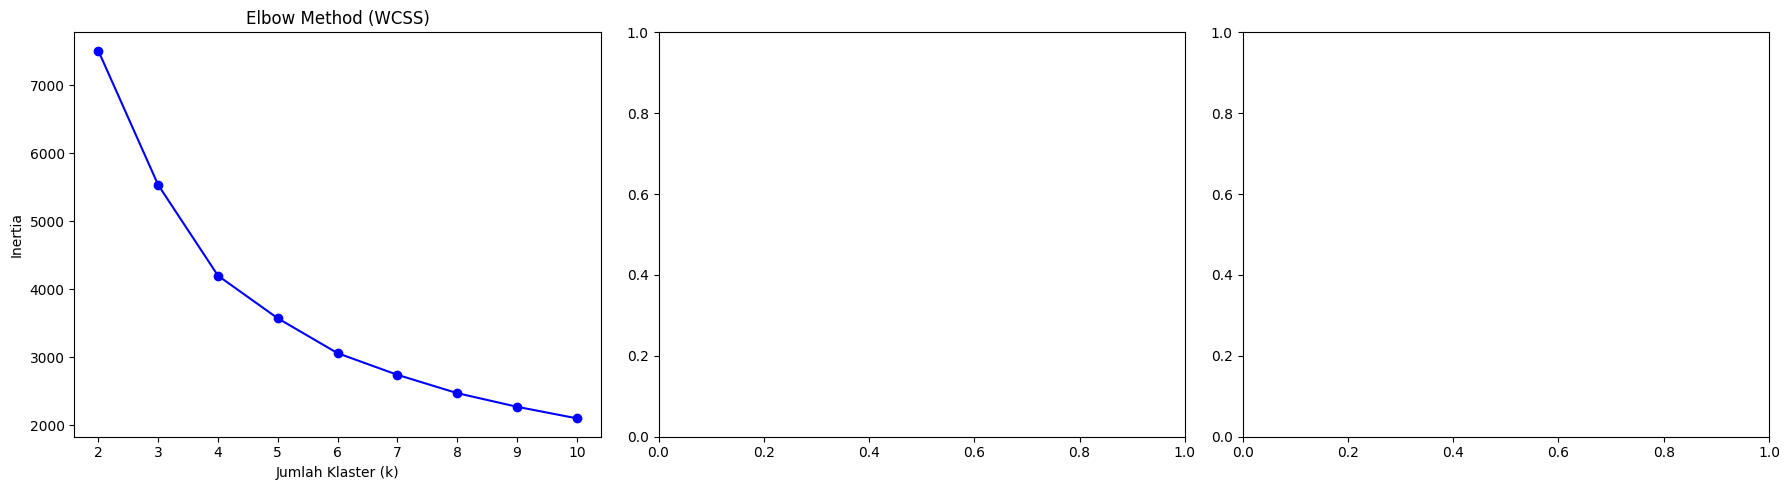

In [15]:
# Rentang K yang akan diuji secara komputasional
k_range = range(2, 11)
wcss = []
silhouette_scores = []
db_scores = []

print("Mengeksekusi evaluasi heuristik untuk K=2 hingga K=10...")
for k in k_range:
    # Set n_init tinggi untuk menghindari jebakan local optima
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(rfm_scaled)
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))
    db_scores.append(davies_bouldin_score(rfm_scaled, labels))

# Pembuatan Panel Visualisasi Evaluasi Klaster
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Elbow Method (Inertia/WCSS) - Mencari titik tekuk
ax[0].plot(k_range, wcss, marker='o', linestyle='-', color='b')
ax[0].set_title('Elbow Method (WCSS)')
ax[0].set_xlabel('Jumlah Klaster (k)')
ax[0].set_ylabel('Inertia')

# # 2. Silhouette Coefficient - Validasi Kerapatan (Mendekati 1 = Optimal)
# ax[1].plot(k_range, silhouette_scores, marker='o', linestyle='-', color='g')
# ax[1].set_title('Silhouette Coefficient (Optimal -> Max)')
# ax[1].set_xlabel('Jumlah Klaster (k)')
# ax[1].set_ylabel('Score')

# # 3. Davies-Bouldin Index - Validasi Separasi (Mendekati 0 = Optimal)
# ax[2].plot(k_range, db_scores, marker='o', linestyle='-', color='r')
# ax[2].set_title('Davies-Bouldin Index (Optimal -> Min)')
# ax[2].set_xlabel('Jumlah Klaster (k)')
# ax[2].set_ylabel('DB Index')

plt.tight_layout()
plt.show()

In [16]:
print("Melakukan klasterisasi...")
# Menggunakan k=4 sesuai temuan evaluasi
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

Melakukan klasterisasi...


KMeans(n_clusters=4, n_init=10, random_state=42)

In [17]:
# Menyimpan label klaster ke dalam dataframe RFM asli
rfm['Cluster'] = kmeans.labels_

In [18]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12608,405,1,415.790003,0
12745,487,2,723.850002,0
12746,541,1,254.549996,0
12747,2,26,8898.480012,2
12749,4,9,6847.359976,2


In [19]:
print(rfm['Cluster'].drop_duplicates().sort_values())

Customer ID
12608    0
12822    1
12747    2
12837    3
Name: Cluster, dtype: int32


# 6. Analisis dan Karakteristik Profil Pelanggan

In [20]:
# Menghitung nilai rata-rata R, F, M dan jumlah pelanggan per klaster
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

In [21]:
print("\n=== Ringkasan Profil Pelanggan per Klaster ===")
print(cluster_summary)


=== Ringkasan Profil Pelanggan per Klaster ===
        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         400.0       1.3    291.9  1733
1          29.8       2.9    769.7  1090
2          31.2      14.3   5579.4  1140
3         244.4       4.8   1623.3  1297


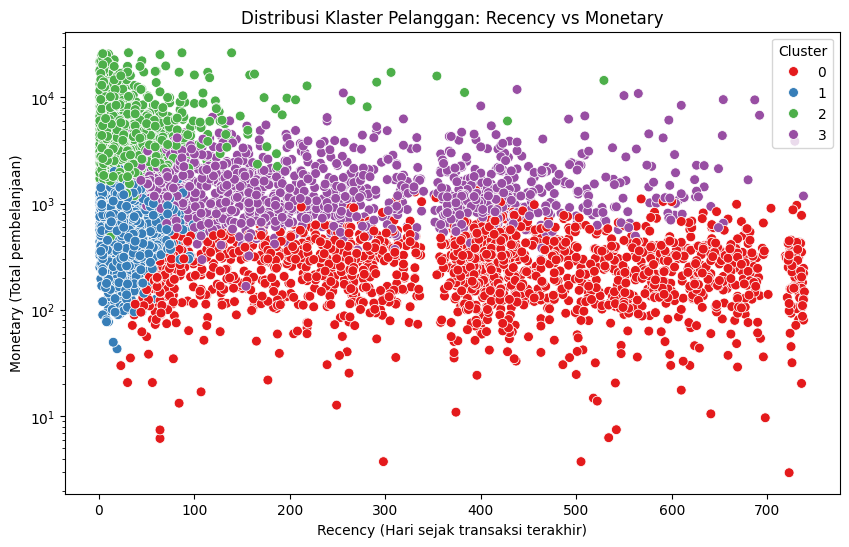

In [22]:
# Visualisasi Distribusi Klaster Recency vs Monetary
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', s=50)
plt.title('Distribusi Klaster Pelanggan: Recency vs Monetary')
plt.xlabel('Recency (Hari sejak transaksi terakhir)')
plt.ylabel('Monetary (Total pembelanjaan)')
plt.yscale('log') # Log scale untuk visibilitas yang lebih baik
plt.show()

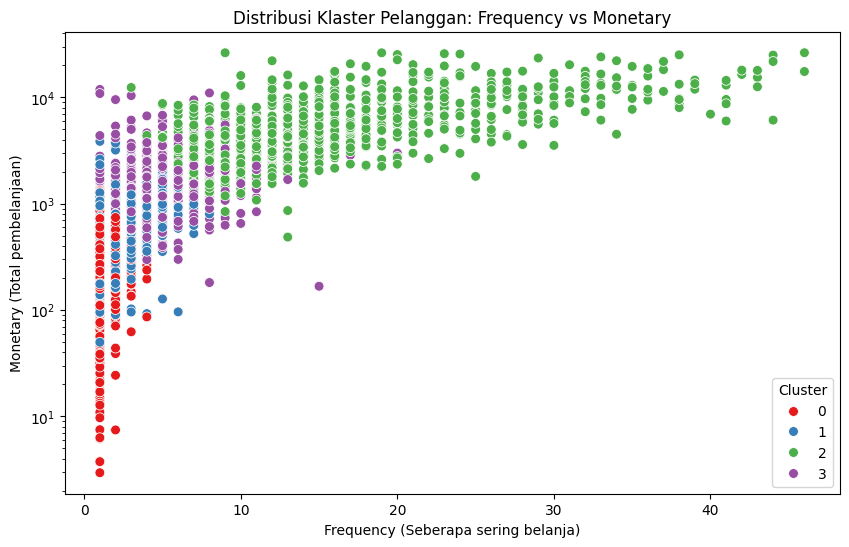

In [23]:
# Visualisasi Distribusi Klaster Frequency vs Monetary
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', s=50)
plt.title('Distribusi Klaster Pelanggan: Frequency vs Monetary')
plt.xlabel('Frequency (Seberapa sering belanja)')
plt.ylabel('Monetary (Total pembelanjaan)')
plt.yscale('log') # Log scale untuk visibilitas yang lebih baik
plt.show()

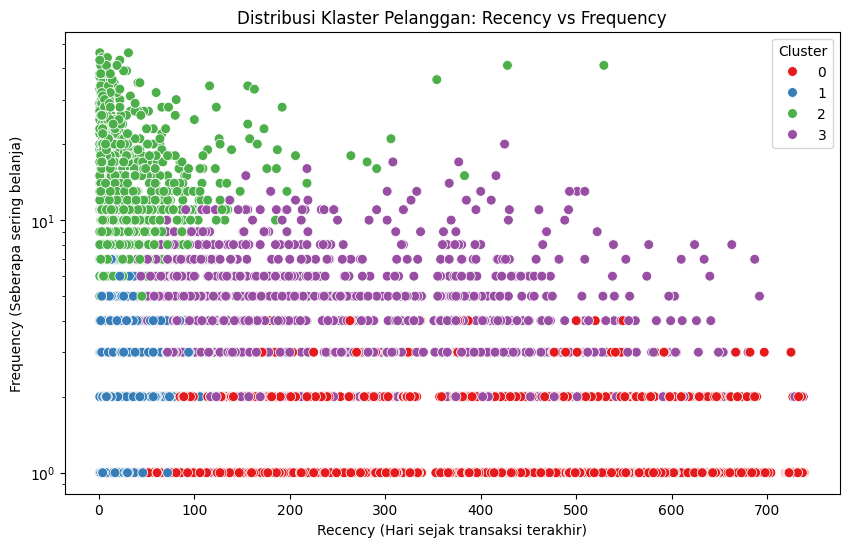

In [24]:
# Visualisasi Distribusi Klaster Recency vs Frequency
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='Set1', s=50)
plt.title('Distribusi Klaster Pelanggan: Recency vs Frequency')
plt.xlabel('Recency (Hari sejak transaksi terakhir)')
plt.ylabel('Frequency (Seberapa sering belanja)')
plt.yscale('log') # Log scale untuk visibilitas yang lebih baik
plt.show()

# HUIM (PAMI)

# 1. Menggabungkan Data Transaksi dengan Klaster RFM

In [25]:
# Pastikan dataframe 'df' (transaksi asli) dan 'rfm' dari kode sebelumnya sudah tersedia.
# Kita petakan setiap 'Customer ID' di transaksi ke klasternya masing-masing.
df_clustered = df.merge(rfm[['Cluster']], on='Customer ID', how='inner')

In [26]:
df_clustered.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Revenue,Cluster
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,83.399998,3
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,81.000000,3
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,81.000000,3
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,100.799995,3
4,489434,21232,STRAWBERRY CERAMIC TRINKET POT,24,2009-12-01 07:45:00,1.25,13085,30.000000,3


In [27]:
# Verifikasi kesamaan jumlah antara customer dan transaksi per cluster
print(df_clustered.groupby('Cluster', as_index=False)['Customer ID'].count())
print(df_clustered.groupby('Cluster', as_index=False)['StockCode'].count())

   Cluster  Customer ID
0        0        39483
1        1        69871
2        2       369280
3        3       126344
   Cluster  StockCode
0        0      39483
1        1      69871
2        2     369280
3        3     126344


In [28]:
# Kita gunakan 'StockCode' sebagai representasi item.
# Menghapus spasi agar tidak error saat diproses oleh PAMI
df_clustered['StockCode'] = df_clustered['StockCode'].astype(str).str.replace(' ', '')

In [29]:
df_clustered.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Revenue,Cluster
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,83.399998,3
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,81.000000,3
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,81.000000,3
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,100.799995,3
4,489434,21232,STRAWBERRY CERAMIC TRINKET POT,24,2009-12-01 07:45:00,1.25,13085,30.000000,3


# 2. Fungsi Transformasi Data ke Format PAMI

In [30]:
# Format HUIM PAMI untuk tiap baris transaksi:
# item1\titem2 : total_utility_transaksi : utility_item1\tutility_item2
# NOTE PENTING: utility tidak diterima PAMI dalam bentuk float

def prepare_pami_format(data_cluster, cluster_label):
    filename = f"huim_cluster_{cluster_label}.txt"
    print(f"\nMenyiapkan file input transaksi Klaster {cluster_label} (Skalasi Sen)...")

    # --- PROSES FILTER NOISE ---
    # Kita buang item yang membawa revenue di bawah £3.10 sebelum agregasi
    # Ini akan mereduksi database sparsity secara signifikan
    data_cluster = data_cluster[data_cluster['Revenue'] >= 3.10]
    
    # Agregasi produk kembar di invoice yang sama berdasarkan kolom 'Revenue'
    grouped = data_cluster.groupby(['Invoice', 'StockCode'])['Revenue'].sum().reset_index()
    
    # Kelompokkan berdasarkan Invoice untuk menulis baris transaksi PAMI
    invoice_groups = grouped.groupby('Invoice')
    
    with open(filename, 'w') as f:
        for invoice, group in invoice_groups:
            # Kalikan 100 (Ubah ke Sen) lalu bulatkan ke Integer Murni
            revenue_cents = (group['Revenue'] * 100).round().astype(int).tolist()
            
            # Abaikan item yang bernilai negatif atau 0 sen
            valid_idx = [i for i, r in enumerate(revenue_cents) if r > 0]
            if not valid_idx:
                continue
                
            items = [str(group['StockCode'].iloc[i]).strip() for i in valid_idx]
            revenues = [revenue_cents[i] for i in valid_idx]
            total_revenue_transaction = sum(revenues)
            
            if total_revenue_transaction <= 0:
                continue
            
            # Gabungkan menjadi format string HUIM PAMI baku (tanpa desimal)
            item_str = '\t'.join(items)
            rev_str = '\t'.join(map(str, revenues))
            
            f.write(f"{item_str}:{total_revenue_transaction}:{rev_str}\n")
            
    print(f"    -> Berhasil menulis file skala sen: {filename}")
    return filename

In [31]:
# Transformasi bentuk data ke dalam format PAMI
for cluster_id in sorted(df_clustered['Cluster'].unique()):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    input_file = prepare_pami_format(cluster_data, cluster_id)


Menyiapkan file input transaksi Klaster 0 (Skalasi Sen)...


/tmp/ipykernel_16/3257472749.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data_cluster.groupby(['Invoice', 'StockCode'])['Revenue'].sum().reset_index()
/tmp/ipykernel_16/3257472749.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invoice_groups = grouped.groupby('Invoice')


    -> Berhasil menulis file skala sen: huim_cluster_0.txt

Menyiapkan file input transaksi Klaster 1 (Skalasi Sen)...


/tmp/ipykernel_16/3257472749.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data_cluster.groupby(['Invoice', 'StockCode'])['Revenue'].sum().reset_index()
/tmp/ipykernel_16/3257472749.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invoice_groups = grouped.groupby('Invoice')


    -> Berhasil menulis file skala sen: huim_cluster_1.txt

Menyiapkan file input transaksi Klaster 2 (Skalasi Sen)...


/tmp/ipykernel_16/3257472749.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data_cluster.groupby(['Invoice', 'StockCode'])['Revenue'].sum().reset_index()
/tmp/ipykernel_16/3257472749.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invoice_groups = grouped.groupby('Invoice')


    -> Berhasil menulis file skala sen: huim_cluster_2.txt

Menyiapkan file input transaksi Klaster 3 (Skalasi Sen)...


/tmp/ipykernel_16/3257472749.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data_cluster.groupby(['Invoice', 'StockCode'])['Revenue'].sum().reset_index()
/tmp/ipykernel_16/3257472749.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invoice_groups = grouped.groupby('Invoice')


    -> Berhasil menulis file skala sen: huim_cluster_3.txt


# 3. Eksekusi PAMI HUIM pada Masing-Masing Klaster

In [32]:
# Import algoritma
from PAMI.highUtilityPattern.basic import EFIM as efim

# EFIM

In [33]:
# # =====================================================================
# # PRE-PROCESSING: Buat Kamus Pemeta ID Produk (StockCode) ke Nama Produk
# # =====================================================================
# # Menghilangkan duplikat untuk mempercepat pencarian (lookup)
# product_mapping = df_clustered.dropna(subset=['StockCode', 'Description']) \
#                               .drop_duplicates(subset=['StockCode']) \
#                               .set_index('StockCode')['Description'] \
#                               .to_dict()

# # --- PARAMETER TUNING ADAPTIF (OTOMATIS) ---
# START_THRESHOLD = 0.01       
# DECAY_FACTOR = 0.98          
# SAFETY_FLOOR = 0.0005        
# TARGET_MIN_PATTERNS = 20     

# for cluster_id in sorted(df_clustered['Cluster'].unique()):
#     print(f"\n{'='*70}")
#     print(f"MEMPROSES KLASTER {cluster_id} SECARA ADAPTIF (SKALA SEN)")
#     print(f"{'='*70}")

#     df_current_cluster = df_clustered[df_clustered['Cluster'] == cluster_id]
#     total_cluster_revenue = df_current_cluster['Revenue'].sum() * 100
#     print(f"Total Revenue Terbaca (Skala Sen): {int(total_cluster_revenue):,}")
    
#     input_file = f"huim_cluster_{cluster_id}.txt"
    
#     current_threshold = START_THRESHOLD
#     patterns = {}
#     obj = None
#     min_util = 0
    
#     while current_threshold >= SAFETY_FLOOR:
#         min_util = int(total_cluster_revenue * current_threshold)
#         if min_util <= 0:
#             min_util = 1
            
#         print(f"-> Mencoba threshold {current_threshold*100:.4f}% | minUtil = {min_util}...")
        
#         try:
#             obj = efim.EFIM(iFile=input_file, minUtil=min_util, sep='\t')
#             obj.mine()
#             patterns = obj.getPatterns()
#             num_patterns = len(patterns)
#             print(f"-> Performa | RAM: {obj.getMemoryUSS() / (1048576):.2f} MB | Waktu: {obj.getRuntime():.4f} detik.")
            
#             if num_patterns >= TARGET_MIN_PATTERNS:
#                 print(f"   [BERHASIL] Menemukan {num_patterns} pola pada threshold {current_threshold*100:.4f}%.")
#                 break
#             elif num_patterns > 0:
#                 print(f"   [PARSIAL] Baru menemukan {num_patterns} pola, mencoba mencari lebih dalam...")
        
#         except ValueError as e:
#             print(f"   [ERROR] Terjadi kesalahan pembacaan format data: {e}")
#             break
            
#         next_threshold = current_threshold * DECAY_FACTOR
#         if next_threshold < SAFETY_FLOOR:
#             print(f"   [BATAS AMAN] Menghentikan pencarian agar RAM tidak meluap (OOM).")
#             break
#         current_threshold = next_threshold
        
#     # =====================================================================
#     # MODIFIKASI: Transformasi Output PAMI ke Struktur CSV Pesanan Anda
#     # =====================================================================
#     if len(patterns) > 0:
#         csv_rows = []
#         itemset_counter = 1
        
#         # Urutkan patterns berdasarkan revenue tertinggi sebelum memberi ID Unik
#         sorted_patterns = sorted(patterns.items(), key=lambda x: int(x[1]), reverse=True)
        
#         for p, u in sorted_patterns:
#             # 1. Generate ID Itemset Unik (ITS001, ITS002, dst)
#             itemset_id = f"ITS{itemset_counter:03d}"
            
#             # 2. Kembalikan Utilitas ke Nilai Pound Terformat (£123.45)
#             revenue_pound = int(u) / 100
#             revenue_formatted = f"£{revenue_pound:.2f}"
            
#             # 3. Pisahkan string itemset bawaan PAMI (\t) menjadi list individual
#             items_in_set = p.split('\t')
            
#             # 4. Pecah baris (Flatten) untuk setiap item di dalam set yang sama
#             for item_id in items_in_set:
#                 # Cari nama produk di kamus, kembalikan ID asli jika nama tidak ditemukan
#                 product_name = product_mapping.get(item_id, f"UNKNOWN_ITEM_{item_id}")
                
#                 csv_rows.append({
#                     'Itemset_ID': itemset_id,
#                     'Revenue': revenue_formatted,
#                     'Product_Name': product_name
#                 })
                
#             itemset_counter += 1
            
#         # Bentuk DataFrame baru hasil restrukturisasi
#         df_csv_output = pd.DataFrame(csv_rows)
        
#         # Simpan langsung ke format CSV bersih tanpa index bawaan pandas
#         csv_filename = f"final_patterns_cluster_{cluster_id}.csv"
#         df_csv_output.to_csv(csv_filename, index=False)
#         print(f"\n   [SUKSES] File output CSV berhasil disimpan: {csv_filename}")
        
#         # Cetak 15 baris pertama dataframe baru sebagai pratinjau hasil
#         print(f"   [Pratinjau Struktur Output CSV - Klaster {cluster_id}]:")
#         print(df_csv_output.head(15).to_string(index=False))
        
#     else:
#         print("   - Tidak ada pola yang melampaui batas minimum safety floor klaster ini.")

In [34]:
# =====================================================================
# PRE-PROCESSING: Buat Kamus Pemeta ID Produk (StockCode) ke Nama Produk
# =====================================================================
product_mapping = df_clustered.dropna(subset=['StockCode', 'Description']) \
                              .drop_duplicates(subset=['StockCode']) \
                              .set_index('StockCode')['Description'] \
                              .to_dict()

# --- PARAMETER TUNING ADAPTIF (OTOMATIS) ---
START_THRESHOLD = 0.01       
DECAY_FACTOR = 0.95          
SAFETY_FLOOR = 0.0005        
TARGET_MIN_PATTERNS = 30     

# --- PARAMETER TAMBAHAN UNTUK JINAKKAN LEDAKAN POLA ---
TARGET_MAX_PATTERNS = 500    # Batas maksimal pola agar tidak over-flooding / OOM
GROWTH_FACTOR = 1.01         # Menaikkan threshold sebesar 1% jika terjadi ledakan pola

for cluster_id in sorted(df_clustered['Cluster'].unique()):
    print(f"\n{'='*70}")
    print(f"MEMPROSES KLASTER {cluster_id} SECARA ADAPTIF (SKALA SEN)")
    print(f"{'='*70}")

    df_current_cluster = df_clustered[df_clustered['Cluster'] == cluster_id]
    total_cluster_revenue = df_current_cluster['Revenue'].sum() * 100
    print(f"Total Revenue Terbaca (Skala Sen): {int(total_cluster_revenue):,}")
    
    input_file = f"huim_cluster_{cluster_id}.txt"
    
    current_threshold = START_THRESHOLD
    patterns = {}
    obj = None
    min_util = 0
    
    # Tracker untuk mencatat threshold yang sudah dicoba agar terhindar dari loop macet (stuck)
    history_thresholds = set()
    
    while current_threshold >= SAFETY_FLOOR:
        # Membulatkan angka threshold agar presisi saat pengecekan duplikasi
        current_threshold = round(current_threshold, 6)
        
        # Pengaman: Jika threshold ini terdeteksi bolak-balik dicoba, hentikan loop
        if current_threshold in history_thresholds:
            print(f"   [ANTI-STUCK] Threshold {current_threshold*100:.4f}% sudah pernah dievaluasi. Mengunci hasil terbaik.")
            break
        history_thresholds.add(current_threshold)

        min_util = int(total_cluster_revenue * current_threshold)
        if min_util <= 0:
            min_util = 1
            
        print(f"-> Mencoba threshold {current_threshold*100:.4f}% | minUtil = {min_util}...")
        
        try:
            obj = efim.EFIM(iFile=input_file, minUtil=min_util, sep='\t')
            obj.mine()
            patterns = obj.getPatterns()
            num_patterns = len(patterns)
            print(f"-> Performa | RAM: {obj.getMemoryUSS() / (1048576):.2f} MB | Waktu: {obj.getRuntime():.4f} detik.")
            
            # -----------------------------------------------------------------
            # EVALUASI KONDISI 1: LEDAKAN ATURAN (RULES EXPLOSION)
            # -----------------------------------------------------------------
            if num_patterns > TARGET_MAX_PATTERNS:
                print(f"   [KOREKSI EXPLOSION] Pola meledak ({num_patterns} pola)! Menaikkan threshold +1%...")
                current_threshold = current_threshold * GROWTH_FACTOR
                continue # Langsung melompat ke awal 'while' untuk mencoba threshold yang lebih tinggi
            
            # -----------------------------------------------------------------
            # EVALUASI KONDISI 2: IDEAL ATAU MINIMAL SUDAH TERPENUHI
            # -----------------------------------------------------------------
            elif TARGET_MIN_PATTERNS <= num_patterns <= TARGET_MAX_PATTERNS:
                print(f"   [BERHASIL] Menemukan jumlah pola ideal ({num_patterns}) pada threshold {current_threshold*100:.4f}%.")
                break
            
            # KONDISI 3: Pola masih di bawah target minimum (0 < pola < 20)
            elif num_patterns > 0:
                print(f"   [PARSIAL] Baru menemukan {num_patterns} pola, mencoba mencari lebih dalam...")
        
        except ValueError as e:
            print(f"   [ERROR] Terjadi kesalahan pembacaan format data: {e}")
            break
            
        # Logika pergerakan default jika Kondisi 3 terpenuhi (Makin turun/makin dalam)
        next_threshold = current_threshold * DECAY_FACTOR
        if next_threshold < SAFETY_FLOOR:
            print(f"   [BATAS AMAN] Menghentikan pencarian agar RAM tidak meluap (OOM).")
            break
        current_threshold = next_threshold
        
    # =====================================================================
    # Transformasi Output PAMI ke Struktur CSV
    # =====================================================================
    if len(patterns) > 0:
        csv_rows = []
        itemset_counter = 1
        
        sorted_patterns = sorted(patterns.items(), key=lambda x: int(x[1]), reverse=True)
        
        for p, u in sorted_patterns:
            itemset_id = f"ITS{itemset_counter:03d}"
            
            revenue_pound = int(u) / 100
            revenue_formatted = f"£{revenue_pound:.2f}"
            
            items_in_set = p.split('\t')
            
            for item_id in items_in_set:
                product_name = product_mapping.get(item_id, f"UNKNOWN_ITEM_{item_id}")
                
                csv_rows.append({
                    'Itemset_ID': itemset_id,
                    'Revenue': revenue_formatted,
                    'Product_Name': product_name
                })
                
            itemset_counter += 1
            
        df_csv_output = pd.DataFrame(csv_rows)
        
        csv_filename = f"final_patterns_cluster_{cluster_id}.csv"
        df_csv_output.to_csv(csv_filename, index=False)
        print(f"\n   [SUKSES] File output CSV berhasil disimpan: {csv_filename}")
        
        print(f"   [Pratinjau Struktur Output CSV - Klaster {cluster_id}]:")
        print(df_csv_output.head(15).to_string(index=False))
        
    else:
        print("   - Tidak ada pola yang melampaui batas minimum safety floor klaster ini.")


MEMPROSES KLASTER 0 SECARA ADAPTIF (SKALA SEN)
Total Revenue Terbaca (Skala Sen): 50,594,617
-> Mencoba threshold 1.0000% | minUtil = 505946...
High Utility patterns were generated successfully using EFIM algorithm
-> Performa | RAM: 364.09 MB | Waktu: 0.1864 detik.
   [PARSIAL] Baru menemukan 1 pola, mencoba mencari lebih dalam...
-> Mencoba threshold 0.9500% | minUtil = 480648...
High Utility patterns were generated successfully using EFIM algorithm
-> Performa | RAM: 364.09 MB | Waktu: 0.0768 detik.
   [PARSIAL] Baru menemukan 1 pola, mencoba mencari lebih dalam...
-> Mencoba threshold 0.9025% | minUtil = 456616...
High Utility patterns were generated successfully using EFIM algorithm
-> Performa | RAM: 364.09 MB | Waktu: 0.0746 detik.
   [PARSIAL] Baru menemukan 2 pola, mencoba mencari lebih dalam...
-> Mencoba threshold 0.8574% | minUtil = 433798...
High Utility patterns were generated successfully using EFIM algorithm
-> Performa | RAM: 364.09 MB | Waktu: 0.0897 detik.
   [PARSI

In [35]:
!cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy
